In [6]:
# ===============================
# SECTION I – TASK 2
# Data Pre-processing
# ===============================

from datasets import load_dataset
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import os
import warnings
import logging

# Download resources
nltk.download('stopwords')
nltk.download('wordnet')

# Load dataset 
ds = load_dataset("GonzaloA/fake_news")

df_train = pd.DataFrame(ds['train'])
df_test  = pd.DataFrame(ds['test'])

# Initialise NLP tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Preprocessing function
def preprocess_text(text):
    text = text.lower()                          # lowercasing
    text = re.sub(r'[^a-z\s]', '', text)         # punctuation removal
    tokens = text.split()                        # tokenisation
    tokens = [lemmatizer.lemmatize(w)            # lemmatisation
              for w in tokens if w not in stop_words]
    return " ".join(tokens)

# Apply preprocessing
df_train['clean_text'] = df_train['text'].apply(preprocess_text)
df_test['clean_text']  = df_test['text'].apply(preprocess_text)

df_train[['text', 'clean_text']].head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,text,clean_text
0,Maury is perhaps one of the trashiest shows on...,maury perhaps one trashiest show television to...
1,"Yesterday, after the father of one of the UCLA...",yesterday father one ucla player arrested chin...
2,MOSCOW (Reuters) - Russia on Wednesday warned ...,moscow reuters russia wednesday warned iraq ku...
3,"House Majority Whip Steve Scalise (R., La.) th...",house majority whip steve scalise r la threw s...
4,It can be said that Late Show host Stephen Col...,said late show host stephen colbert clearly gi...


Train rows: 24353
Test rows : 8117
label
1    13195
0    11158
Name: count, dtype: int64


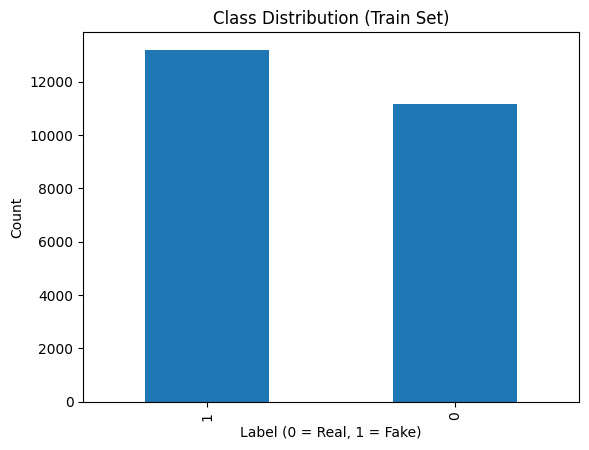

TF-IDF Train shape: (24353, 5000)
TF-IDF Test shape : (8117, 5000)


In [3]:
# ===============================
# SECTION II – TASK 1
# Dataset Analysis & Feature Extraction
# ===============================

import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# ---- Dataset size ----
print("Train rows:", len(df_train))
print("Test rows :", len(df_test))

# ---- Class distribution ----
print(df_train['label'].value_counts())

df_train['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Train Set)")
plt.xlabel("Label (0 = Real, 1 = Fake)")
plt.ylabel("Count")
plt.show()

# ---- Text length statistics ----
df_train['text_length'] = df_train['text'].apply(lambda x: len(x.split()))
df_test['text_length']  = df_test['text'].apply(lambda x: len(x.split()))

df_train['text_length'].describe()

# ---- Feature Extraction (TF-IDF) ----
tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(df_train['clean_text'])
X_test  = tfidf.transform(df_test['clean_text'])

y_train = df_train['label']
y_test  = df_test['label']

print("TF-IDF Train shape:", X_train.shape)
print("TF-IDF Test shape :", X_test.shape)


Rule-based model sample output


,clean_text,label,rule_pred
0,joe digenova around dc decade seen probably se...,0,1
1,recent interview cnn former senator republican...,0,0
2,three clown left gop clown car republican ever...,0,0
3,kathmandu reuters nepali began voting final ro...,1,0
4,washington reuters american likely believe wea...,1,0
5,wellington reuters new zealand ruling national...,1,0
6,washington reuters special counsel investigati...,1,0
7,london reuters london canary wharf docklands l...,1,0
8,discussing shooting crime first three presiden...,0,0
9,washington reuters u president donald trump be...,1,0


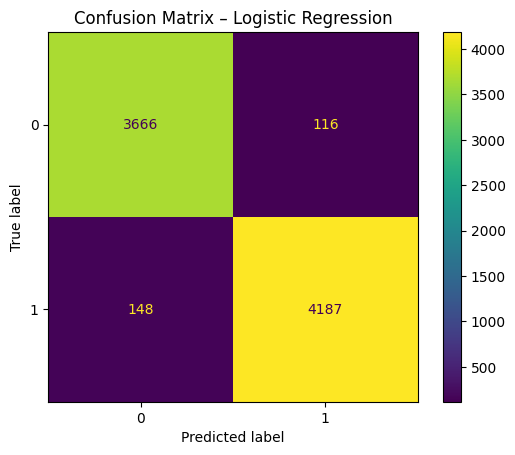

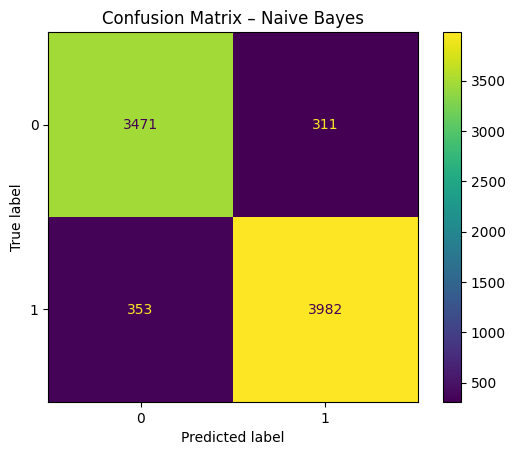

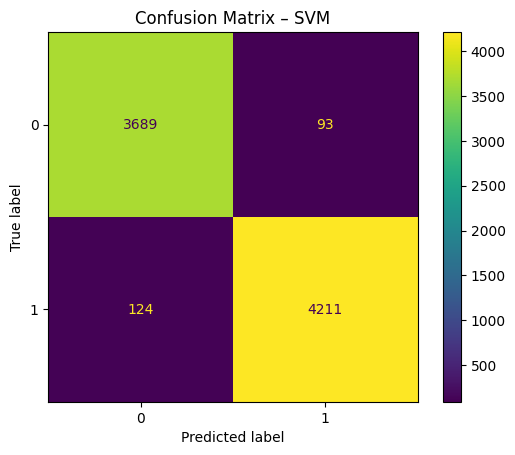

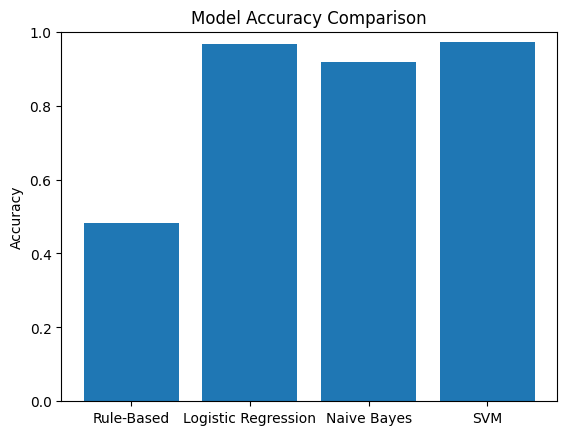


--- MODEL ACCURACY SUMMARY ---
Rule-Based Accuracy: 0.4814586669951953
Logistic Regression Accuracy: 0.9674756683503758
Naive Bayes Accuracy: 0.9181963779721573
SVM Accuracy: 0.9732659849698164


In [ ]:
# ======================================================
# SECTION III – TASK 1
# ======================================================

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

# ------------------------------------------------------
# RULE-BASED APPROACH
# ------------------------------------------------------

fake_keywords = [
    "breaking", "shocking", "unbelievable",
    "secret", "exposed", "hoax", "scam"
]

def rule_based_classifier(text):
    for word in fake_keywords:
        if word in text:
            return 1
    return 0

df_test['rule_pred'] = df_test['clean_text'].apply(rule_based_classifier)

# ---- Rule-based output (table) ----
print("Rule-based model sample output")
display(df_test[['clean_text', 'label', 'rule_pred']].head(10))

rule_acc = accuracy_score(y_test, df_test['rule_pred'])


# ------------------------------------------------------
# B. MACHINE LEARNING MODELS
# ------------------------------------------------------

# --------------------
#  Logistic Regression
# --------------------
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)


ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)
plt.title("Confusion Matrix – Logistic Regression")
plt.show()


nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, nb_pred)
plt.title("Confusion Matrix – Naive Bayes")
plt.show()

# --------------------
# 3. Support Vector Machine (SVM)
# --------------------
svm = LinearSVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

# ---- GRAPH 4: SVM Confusion Matrix ----
ConfusionMatrixDisplay.from_predictions(y_test, svm_pred)
plt.title("Confusion Matrix – SVM")
plt.show()

# ------------------------------------------------------
# MODEL COMPARISON (Accuracy Bar Chart)
# ------------------------------------------------------

lr_acc  = accuracy_score(y_test, lr_pred)
nb_acc  = accuracy_score(y_test, nb_pred)
svm_acc = accuracy_score(y_test, svm_pred)

models = ['Rule-Based', 'Logistic Regression', 'Naive Bayes', 'SVM']
scores = [rule_acc, lr_acc, nb_acc, svm_acc]

plt.figure()
plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# ------------------------------------------------------
# SUMMARY PRINT
# ------------------------------------------------------

print("\n--- MODEL ACCURACY SUMMARY ---")
print("Rule-Based Accuracy:", rule_acc)
print("Logistic Regression Accuracy:", lr_acc)
print("Naive Bayes Accuracy:", nb_acc)
print("SVM Accuracy:", svm_acc)


Rule-Based Accuracy: 0.4814586669951953

Logistic Regression Metrics
Accuracy : 0.9674756683503758
Precision: 0.9730420636765048
Recall   : 0.9658592848904267
F1-score : 0.9694373697615188
ROC-AUC  : 0.9675938412818078


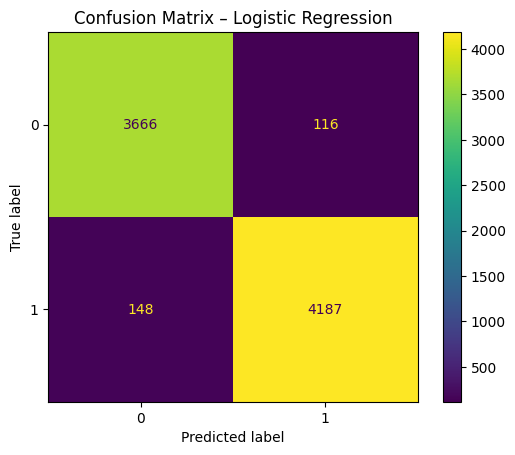

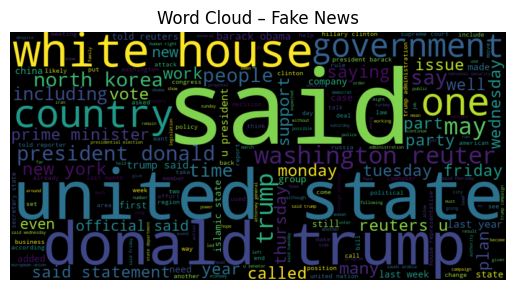

In [5]:
# ===============================
# SECTION III – TASK 2
# Evaluation & Visualisation
# ===============================

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay
)

# ---- Rule-based evaluation ----
print("Rule-Based Accuracy:",
      accuracy_score(y_test, df_test['rule_pred']))

# ---- Logistic Regression evaluation ----
print("\nLogistic Regression Metrics")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1-score :", f1_score(y_test, lr_pred))
print("ROC-AUC  :", roc_auc_score(y_test, lr_pred))

# ---- Confusion Matrix ----
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

# ---- Word Cloud ----
from wordcloud import WordCloud

fake_text = " ".join(
    df_train[df_train['label'] == 1]['clean_text']
)

wordcloud = WordCloud(
    width=800, height=400,
    background_color='black'
).generate(fake_text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud – Fake News")
plt.show()
